In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [2]:
orders=pd.read_csv(r'C:\Users\QC#\OneDrive\Documents\orders.csv')

In [3]:
pizza_types=pd.read_csv(r'C:\Users\QC#\OneDrive\Documents\pizza_types.csv',encoding='latin1')

In [4]:
orders.duplicated().sum()

np.int64(0)

In [5]:
orders.isnull().sum()

order_id    0
date        0
time        0
dtype: int64

In [6]:
pizza_types.isna().sum()

pizza_type_id    0
name             0
category         0
ingredients      0
dtype: int64

In [7]:
df=pd.to_datetime(orders['date'])
df=pd.to_datetime(orders['time'])

C:\Users\QC#\AppData\Local\Temp\ipykernel_12552\3001065003.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df=pd.to_datetime(orders['time'])


In [8]:
pizza_types['ingredients']=pizza_types['ingredients'].str.lower()

In [9]:
pizza_types

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"barbecued chicken, red peppers, green peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"chicken, artichoke, spinach, garlic, jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"chicken, red onions, red peppers, mushrooms, a..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"chicken, tomatoes, red peppers, spinach, garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"chicken, tomatoes, red peppers, red onions, ja..."
5,thai_ckn,The Thai Chicken Pizza,Chicken,"chicken, pineapple, tomatoes, red peppers, tha..."
6,big_meat,The Big Meat Pizza,Classic,"bacon, pepperoni, italian sausage, chorizo sau..."
7,classic_dlx,The Classic Deluxe Pizza,Classic,"pepperoni, mushrooms, red onions, red peppers,..."
8,hawaiian,The Hawaiian Pizza,Classic,"sliced ham, pineapple, mozzarella cheese"
9,ital_cpcllo,The Italian Capocollo Pizza,Classic,"capocollo, red peppers, tomatoes, goat cheese,..."


In [10]:
pizza_types['ingredients']=pizza_types['ingredients'].apply(lambda x:[i.strip().lower() for i in x.split(',')])

In [11]:
pizza_types.head(10)

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"[barbecued chicken, red peppers, green peppers..."
1,cali_ckn,The California Chicken Pizza,Chicken,"[chicken, artichoke, spinach, garlic, jalapeno..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"[chicken, red onions, red peppers, mushrooms, ..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"[chicken, tomatoes, red peppers, spinach, garl..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"[chicken, tomatoes, red peppers, red onions, j..."
5,thai_ckn,The Thai Chicken Pizza,Chicken,"[chicken, pineapple, tomatoes, red peppers, th..."
6,big_meat,The Big Meat Pizza,Classic,"[bacon, pepperoni, italian sausage, chorizo sa..."
7,classic_dlx,The Classic Deluxe Pizza,Classic,"[pepperoni, mushrooms, red onions, red peppers..."
8,hawaiian,The Hawaiian Pizza,Classic,"[sliced ham, pineapple, mozzarella cheese]"
9,ital_cpcllo,The Italian Capocollo Pizza,Classic,"[capocollo, red peppers, tomatoes, goat cheese..."


In [12]:
engine=create_engine('postgresql://#Give Your ows Path Due to Security Issue I Cannot Share/Pizza_sale')

In [13]:
pizzas=pd.read_sql('select * from pizzas',engine)

In [14]:
pizzas

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75
...,...,...,...,...
91,spinach_fet_m,spinach_fet,M,16.00
92,spinach_fet_l,spinach_fet,L,20.25
93,veggie_veg_s,veggie_veg,S,12.00
94,veggie_veg_m,veggie_veg,M,16.00


In [15]:
order_details=pd.read_sql('select * from order_detail',engine)

In [16]:
order_details

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1
...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1
48616,48617,21348,four_cheese_l,1
48617,48618,21348,napolitana_s,1
48618,48619,21349,mexicana_l,1


In [17]:
order_details.isna().sum()

order_details_id    0
order_id            0
pizza_id            0
quantity            0
dtype: int64

In [18]:
order_details.duplicated().sum()

np.int64(0)

In [19]:
pizzas.isna().sum()

pizza_id         0
pizza_type_id    0
size             0
price            0
dtype: int64

In [20]:
pizzas.duplicated().sum()

np.int64(0)

In [21]:
order_details['quantity']=order_details['quantity'].astype(int)

In [22]:
pizza_master=pd.merge(order_details,pizzas,
                     on='pizza_id')

In [23]:
pizza_master.head(10)

,order_details_id,order_id,pizza_id,quantity,pizza_type_id,size,price
0,1,1,hawaiian_m,1,hawaiian,M,13.25
1,2,2,classic_dlx_m,1,classic_dlx,M,16.00
2,3,2,five_cheese_l,1,five_cheese,L,18.50
3,4,2,ital_supr_l,1,ital_supr,L,20.75
4,5,2,mexicana_m,1,mexicana,M,16.00
5,6,2,thai_ckn_l,1,thai_ckn,L,20.75
6,7,3,ital_supr_m,1,ital_supr,M,16.50
7,8,3,prsc_argla_l,1,prsc_argla,L,20.75
8,9,4,ital_supr_m,1,ital_supr,M,16.50
9,10,5,ital_supr_m,1,ital_supr,M,16.50


In [24]:
#Total_revenue
pizza_master['Revenue']=pizza_master['quantity']*pizza_master['price']
print(t_revenue:=pizza_master['Revenue'].sum())
#total_pizza_sold
print(t_sold:=pizza_master['quantity'].sum())
#total_orders
print(t_order:=pizza_master['order_id'].nunique())

817860.0499999999
49574
21350


In [25]:
#Top 10 selling pizza
step1=pd.merge(order_details,pizzas,on='pizza_id')
t_pizza=pd.merge(step1,pizza_types,on='pizza_type_id')
top_pizza=t_pizza.groupby('name')['quantity'].sum().sort_values(ascending=False).head(10)
print(top_pizza)

name
The Classic Deluxe Pizza        2453
The Barbecue Chicken Pizza      2432
The Hawaiian Pizza              2422
The Pepperoni Pizza             2418
The Thai Chicken Pizza          2371
The California Chicken Pizza    2370
The Sicilian Pizza              1938
The Spicy Italian Pizza         1924
The Southwest Chicken Pizza     1917
The Big Meat Pizza              1914
Name: quantity, dtype: int64


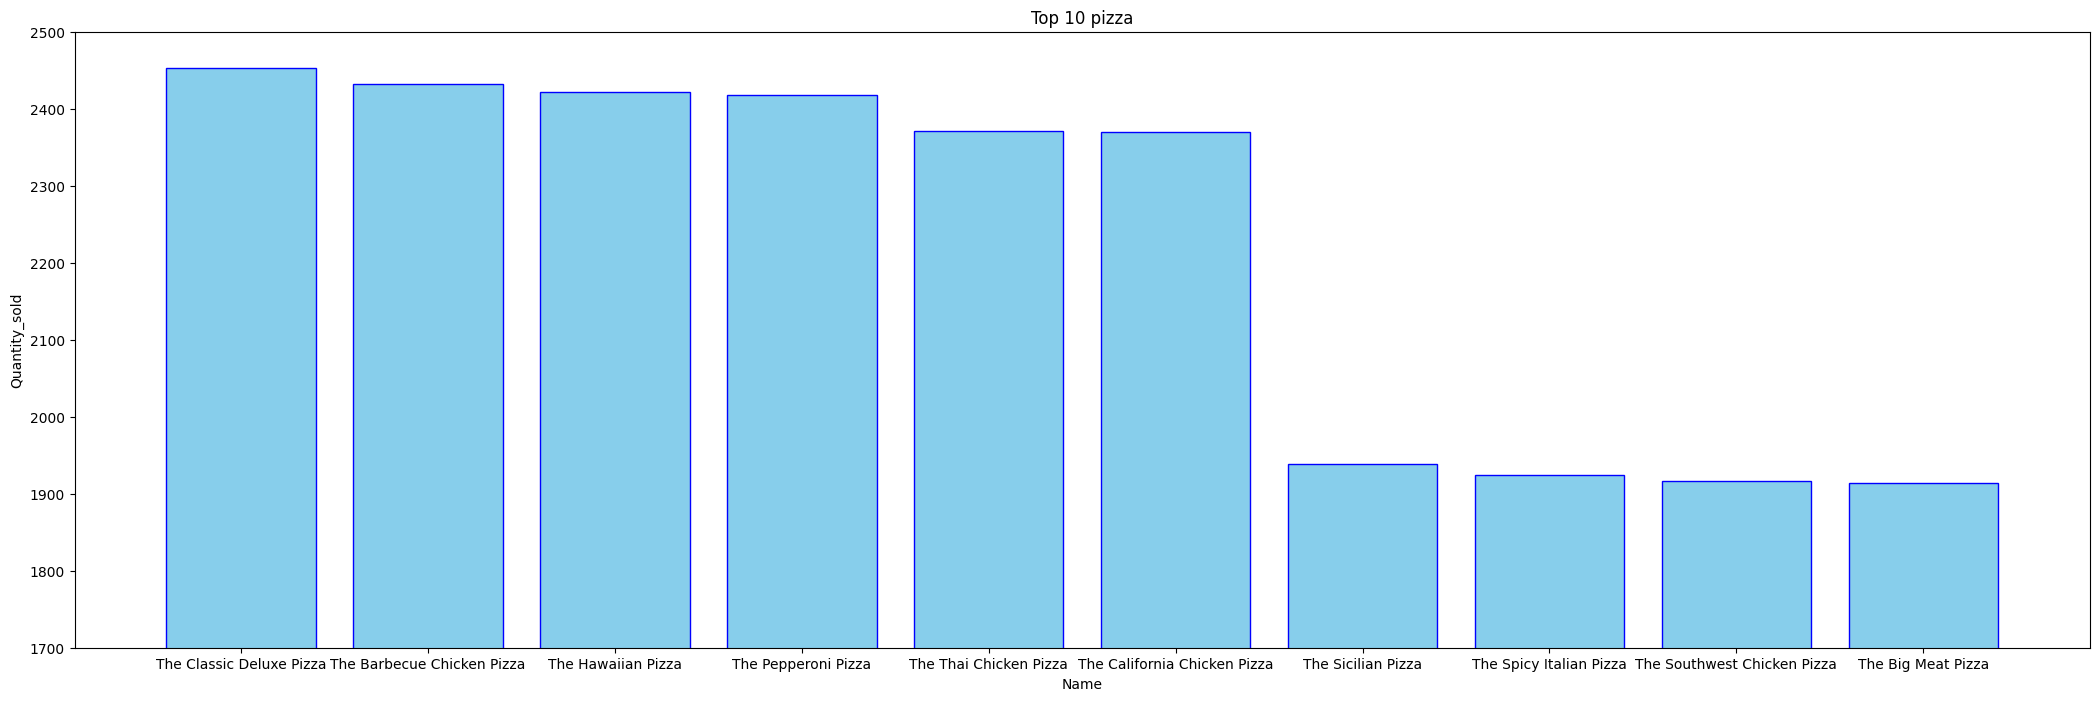

In [26]:
#Graph for top 10
plt.figure(figsize=(26,8))
plt.bar(top_pizza.index,top_pizza.values,color='skyblue',edgecolor='b')
plt.ylim(1700,2500)
plt.title('Top 10 pizza')
plt.xlabel('Name')
plt.ylabel('Quantity_sold')
plt.show()

In [27]:
#Revenue by category
t_pizza['revenue']=t_pizza['price']*t_pizza['quantity']
Revenue_By_Category=t_pizza.groupby('category')['revenue'].sum().reset_index()
print(Revenue_By_Category)

  category    revenue
0  Chicken  195919.50
1  Classic  220053.10
2  Supreme  208197.00
3   Veggie  193690.45


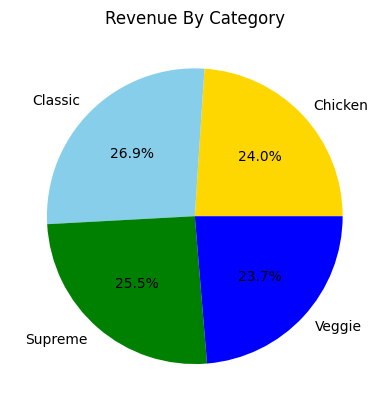

In [28]:
plt.pie(Revenue_By_Category['revenue'],labels=Revenue_By_Category['category'],
       autopct='%1.1f%%',colors=['gold','skyblue','green','blue'])
plt.title('Revenue By Category')
plt.show()

In [29]:
#Peak hourd of the day
orders['time']=pd.to_datetime(orders['time'],format='%H:%M:%S')
orders['hour']=orders['time'].dt.hour
busy_hours=orders.groupby('hour')['order_id'].count()
print(busy_hours)

hour
9        1
10       8
11    1231
12    2520
13    2455
14    1472
15    1468
16    1920
17    2336
18    2399
19    2009
20    1642
21    1198
22     663
23      28
Name: order_id, dtype: int64


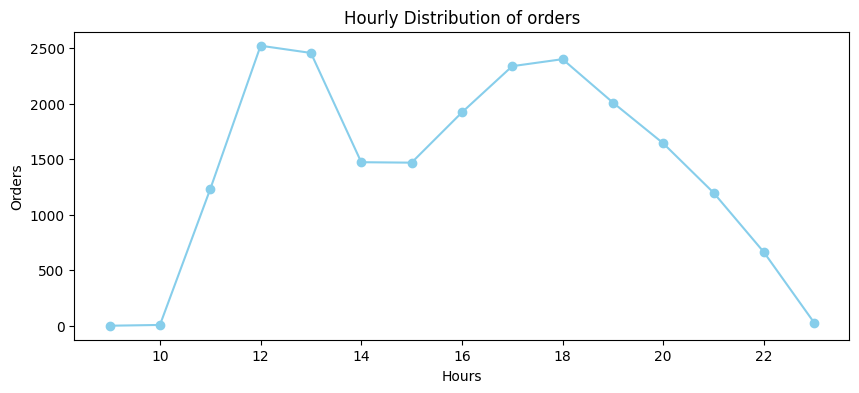

In [30]:
plt.figure(figsize=(10,4))
plt.plot(busy_hours.index,busy_hours.values,marker='o',color='skyblue')
plt.title('Hourly Distribution of orders')
plt.ylabel('Orders')
plt.xlabel('Hours')
plt.show()

In [31]:
#Aov(average order_value)
t_revenue=pizza_master['Revenue'].sum()
t_orders=t_pizza['order_id'].nunique()
aov=t_revenue/t_orders
print(aov)

38.30726229508196


In [32]:
#Avg pizza_order_per_day
step2=pd.merge(pizza_master,orders, on='order_id')
daily_sale=step2.groupby('date')['quantity'].sum()
daily_sale.mean()

np.float64(138.47486033519553)

In [35]:
#Cumulated Revenue (daily)(running_total)
daily_revenue=daily_sale=step2.groupby('date')['Revenue'].sum().reset_index()
daily_revenue['cum_rev']=daily_revenue['Revenue'].cumsum()
print(daily_revenue.head(10))

         date  Revenue   cum_rev
0  2015-01-01  2713.85   2713.85
1  2015-01-02  2731.90   5445.75
2  2015-01-03  2662.40   8108.15
3  2015-01-04  1755.45   9863.60
4  2015-01-05  2065.95  11929.55
5  2015-01-06  2428.95  14358.50
6  2015-01-07  2202.20  16560.70
7  2015-01-08  2838.35  19399.05
8  2015-01-09  2127.35  21526.40
9  2015-01-10  2463.95  23990.35


In [36]:
m_pizza=pd.merge(orders,t_pizza,on='order_id')

In [47]:
orders_details=pd.merge(order_details,orders, on='order_id')

In [48]:
pizzas_and_types=pd.merge(pizza_types,pizzas,on='pizza_type_id')

In [52]:
orders_details.to_csv('orders_detail.csv',index=False)

In [53]:
pizzas_and_types.to_csv('pizzas_and_type.csv',index=False)